# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Evina Ftriyani | 5054251013|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

### 1. Persiapan Dataset dan Eksplorasi Awal

In [3]:
# import semua library yang dipake buat tugas ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [4]:
# baca dataset mushroom, terus liat 5 baris pertama buat mastiin datanya kebaca
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
# liat ukuran data, tipe data tiap kolom, sama cek missing value pake isnull
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(8124, 23)
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0

In [6]:
# isnull() diatas gabakal kedetect soalnya missing value di dataset ini ditulis pake '?', bukan NaN. jadi dicek manual satu-satu
for col in df.columns:
    jumlah = 0
    for isi in df[col]:
        if isi == '?':
            jumlah = jumlah + 1
    if jumlah > 0:
        print(col, "ada", jumlah, "nilai '?'")

stalk-root ada 2480 nilai '?'


In [7]:
# liat tiap kolom isinya kategori apa aja dan ada berapa macem nilai uniknya
for col in df.columns:
    print(col, "->", df[col].nunique(), "nilai unik")
    print(df[col].unique())
    print("")

class -> 2 nilai unik
<StringArray>
['p', 'e']
Length: 2, dtype: str

cap-shape -> 6 nilai unik
<StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str

cap-surface -> 4 nilai unik
<StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str

cap-color -> 10 nilai unik
<StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str

bruises -> 2 nilai unik
<StringArray>
['t', 'f']
Length: 2, dtype: str

odor -> 9 nilai unik
<StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str

gill-attachment -> 2 nilai unik
<StringArray>
['f', 'a']
Length: 2, dtype: str

gill-spacing -> 2 nilai unik
<StringArray>
['c', 'w']
Length: 2, dtype: str

gill-size -> 2 nilai unik
<StringArray>
['n', 'b']
Length: 2, dtype: str

gill-color -> 12 nilai unik
<StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str

stalk-shape -> 2 nilai unik
<StringArray>
['e', 't']
Length: 2, dtype: str

stalk-root -> 5 nilai un

class
e    4208
p    3916
Name: count, dtype: int64


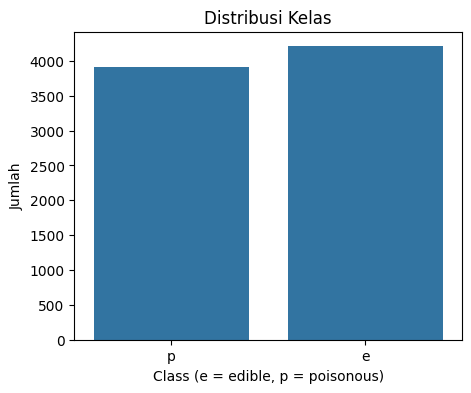

In [9]:
# liat perbandingan jumlah data edible (e) sama poisonous (p), buat cek imbalance apa engga
print(df['class'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df)
plt.title('Distribusi Kelas')
plt.xlabel('Class (e = edible, p = poisonous)')
plt.ylabel('Jumlah')
plt.show()

##### EDA Tambahan (odor vs class)

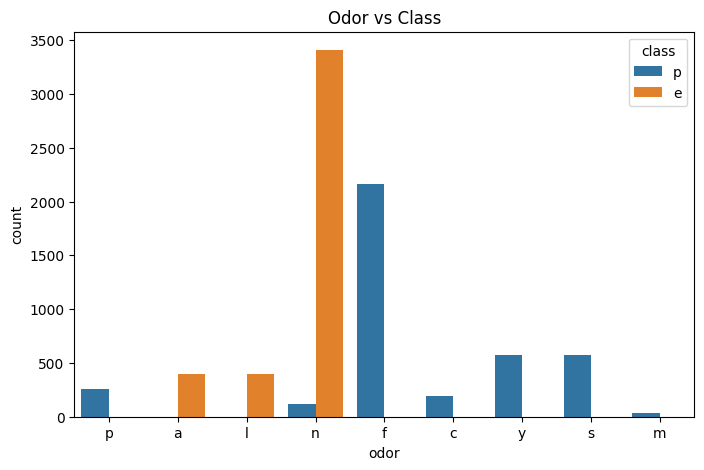

In [10]:
# nyoba liat apakah odor (bau) ngaruh ke class jamur beracun atau engga
plt.figure(figsize=(8,5))
sns.countplot(x='odor', hue='class', data=df)
plt.title('Odor vs Class')
plt.show()

### 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [16]:
# tangani missing value stalk-root, nilai '?' dijadiin kategori baru aja
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

# cari kolom yang cuma punya 1 nilai unik, kolom kayak gitu percuma dipake karena ga ngasih informasi
kolom_dibuang = []
for col in df.columns:
    if df[col].nunique() == 1:
        kolom_dibuang.append(col)

print("kolom yang mau dibuang:", kolom_dibuang)

# langsung dibuang kolomnya
df = df.drop(columns=kolom_dibuang)
print(df.shape)

kolom yang mau dibuang: []
(8124, 22)


In [17]:
# X = fitur buat prediksi, y = target yang mau diprediksi (class)
X = df.drop(columns=['class'])
y = df['class']

# ubah target dari huruf e/p jadi angka 0/1 soalnya model butuh angka
le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)
print(y[:10])

['e' 'p']
[1 0 0 1 0 0 0 0 1 0]


In [18]:
# bagi data jadi 80% train dan 20% test, stratify=y biar perbandingan e sama p nya tetep proporsional
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("data train:", X_train.shape)
print("data test:", X_test.shape)

data train: (6499, 21)
data test: (1625, 21)


In [19]:
# categorical NB butuh input angka integer per kategori, jadi tiap kategori diubah pake OrdinalEncoder
# fit cuma di data train biar ga bocor info ke test (data leakage)
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_ordinal = ordinal_enc.fit_transform(X_train)
X_test_ordinal = ordinal_enc.transform(X_test)

print(X_train_ordinal[:5])

[[ 2.  3.  9.  0.  2.  1.  0.  0.  2.  0.  0.  1.  1.  6.  0.  2.  1.  2.
   1.  5.  1.]
 [ 5.  2.  5.  1.  5.  1.  0.  0.  1.  0.  3.  2.  2.  2.  7.  2.  2.  0.
   7.  1.  6.]
 [ 0.  2.  3.  0.  5.  1.  1.  0. 10.  0.  3.  1.  2.  7.  7.  2.  2.  4.
   7.  3.  1.]
 [ 2.  2.  4.  0.  7.  1.  0.  1.  0.  1.  3.  1.  1.  6.  7.  2.  1.  0.
   7.  4.  0.]
 [ 3.  3.  4.  0.  2.  1.  0.  1.  0.  1.  3.  2.  1.  6.  6.  2.  1.  0.
   7.  4.  4.]]


In [20]:
# bernoulli sama multinomial butuh input binary 0/1, jadi tiap kategori diubah jadi kolom sendiri pake OneHotEncoder
onehot_enc = OneHotEncoder(handle_unknown='ignore')

X_train_onehot = onehot_enc.fit_transform(X_train)
X_test_onehot = onehot_enc.transform(X_test)

print(X_train_onehot.shape)

(6499, 116)


### 3. Eksperimen Model

#### 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [21]:
# ini yang paling cocok soalnya emang semua fitur kategorikal
model_cat = CategoricalNB()
model_cat.fit(X_train_ordinal, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [22]:
# prediksi ke data test, sama ambil probabilitasnya juga buat roc curve nanti
pred_cat = model_cat.predict(X_test_ordinal)
prob_cat = model_cat.predict_proba(X_test_ordinal)[:, 1]

print(pred_cat[:10])

[1 0 0 1 1 0 0 0 0 0]


### 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [23]:
# pake data yang onehot, soalnya bernoulli maunya binary
model_bern = BernoulliNB()
model_bern.fit(X_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [24]:
pred_bern = model_bern.predict(X_test_onehot)
prob_bern = model_bern.predict_proba(X_test_onehot)[:, 1]

print(pred_bern[:10])

[1 0 0 1 1 0 0 0 0 0]


### 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [25]:
# ini juga pake onehot walaupun sebenernya multinomial buat data count
model_multi = MultinomialNB()
model_multi.fit(X_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [26]:
pred_multi = model_multi.predict(X_test_onehot)
prob_multi = model_multi.predict_proba(X_test_onehot)[:, 1]

print(pred_multi[:10])

[1 0 0 1 1 0 0 0 0 0]


# 4. Evaluasi Model

In [ ]:
# hitung accuracy, precision, recall, f1 buat masing-masing model
acc_cat = accuracy_score(y_test, pred_cat)
prec_cat = precision_score(y_test, pred_cat)
rec_cat = recall_score(y_test, pred_cat)
f1_cat = f1_score(y_test, pred_cat)

acc_bern = accuracy_score(y_test, pred_bern)
prec_bern = precision_score(y_test, pred_bern)
rec_bern = recall_score(y_test, pred_bern)
f1_bern = f1_score(y_test, pred_bern)

acc_multi = accuracy_score(y_test, pred_multi)
prec_multi = precision_score(y_test, pred_multi)
rec_multi = recall_score(y_test, pred_multi)
f1_multi = f1_score(y_test, pred_multi)

# terus masukin ke tabel biar mudah lihat perbandingannya
data_hasil = {
    'Model': ['Categorical NB', 'Bernoulli NB', 'Multinomial NB'],
    'Accuracy': [acc_cat, acc_bern, acc_multi],
    'Precision': [prec_cat, prec_bern, prec_multi],
    'Recall': [rec_cat, rec_bern, rec_multi],
    'F1-Score': [f1_cat, f1_bern, f1_multi]
}

df_hasil = pd.DataFrame(data_hasil)
df_hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


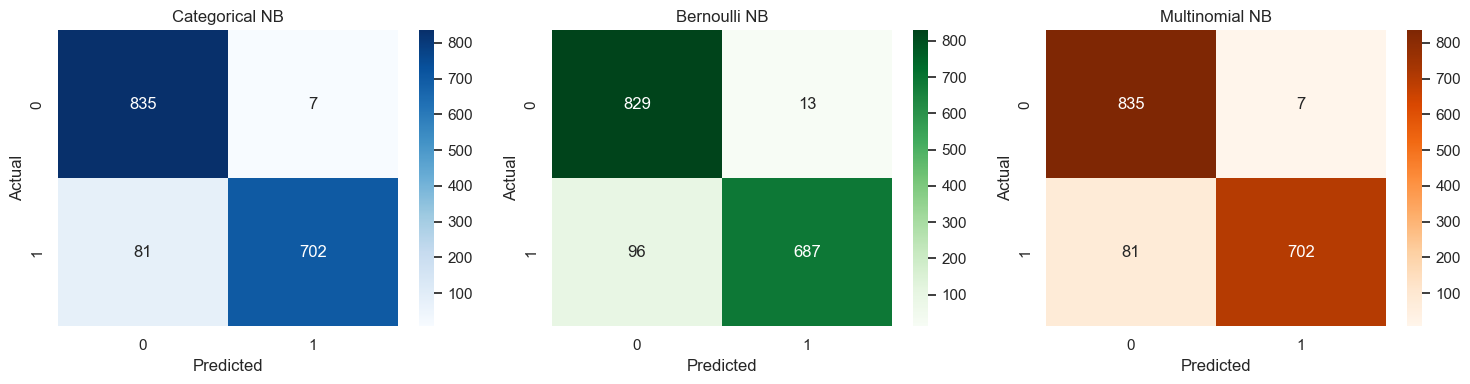

In [34]:
# bikin confusion matrix masing-masing model terus digambar sejajar pake subplot
cm_cat = confusion_matrix(y_test, pred_cat)
cm_bern = confusion_matrix(y_test, pred_bern)
cm_multi = confusion_matrix(y_test, pred_multi)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Categorical NB')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_bern, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Bernoulli NB')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Multinomial NB')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

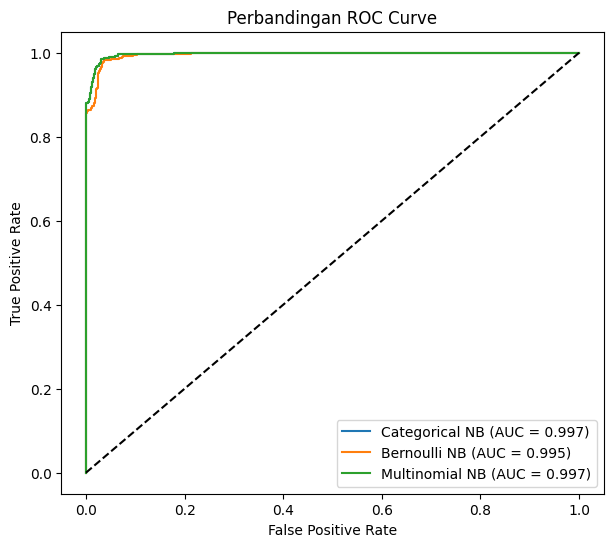

In [29]:
# bikin roc curve buat liat performa ketiga model, makin gede AUC nya makin bagus
fpr_cat, tpr_cat, thresh1 = roc_curve(y_test, prob_cat)
fpr_bern, tpr_bern, thresh2 = roc_curve(y_test, prob_bern)
fpr_multi, tpr_multi, thresh3 = roc_curve(y_test, prob_multi)

auc_cat = auc(fpr_cat, tpr_cat)
auc_bern = auc(fpr_bern, tpr_bern)
auc_multi = auc(fpr_multi, tpr_multi)

plt.figure(figsize=(7,6))
plt.plot(fpr_cat, tpr_cat, label='Categorical NB (AUC = ' + str(round(auc_cat,3)) + ')')
plt.plot(fpr_bern, tpr_bern, label='Bernoulli NB (AUC = ' + str(round(auc_bern,3)) + ')')
plt.plot(fpr_multi, tpr_multi, label='Multinomial NB (AUC = ' + str(round(auc_multi,3)) + ')')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Perbandingan ROC Curve')
plt.legend()
plt.show()

# 5. Analisis

Dari hasil eksperimen, ini rangkuman hasilnya:

| Model | Accuracy | Precision | Recall | F1-Score | AUC |
|---|---|---|---|---|---|
| Categorical NB | 0.9458 | 0.9901 | 0.8966 | 0.9410 | 0.997 |
| Bernoulli NB | 0.9329 | 0.9814 | 0.8774 | 0.9265 | 0.995 |
| Multinomial NB | 0.9458 | 0.9901 | 0.8966 | 0.9410 | 0.997 |

Yang menarik, hasil Categorical NB dan Multinomial NB itu sama persis, sampai confusion matrix-nya juga kembar (TN=835, FP=7, FN=81, TP=702). Bernoulli NB agak beda tipis, sedikit lebih jelek (TN=829, FP=13, FN=96, TP=687).

Kenapa bisa gitu? Menurut ku  gara-gara representasi datanya. Categorical NB pakai OrdinalEncoder, jadi tiap kategori langsung diubah jadi angka terus dihitung probabilitasnya. Multinomial NB pake OneHotEncoder yang isinya cuma 0 sama 1, dan karena tiap fitur cuma punya 1 kategori yang aktif (bukan angka count beneran kayak jumlah kata di teks), perhitungannya jadi ujung-ujungnya sama saja kayak Categorical NB. Makanya hasilnya identik.

Bernoulli NB beda ceritanya, soalnya dia nggak cuma liat kategori yang muncul (nilai 1) tapi juga ikut menghitung kategori yang nggak muncul (nilai 0). Nah dataset ini abis di-onehot jadi 116 kolom, jadi nilai 0-nya jauh lebih banyak dari nilai 1. Ini kemungkinan bikin model agak "keganggu" sama banyaknya info nol tadi, makanya recall-nya turun jadi 87.74% dibanding dua model lain yang 89.66%.

Kalo diliat dari confusion matrix, ketiga model sama-sama punya FP yang dikit (7-13), tapi FN-nya lumayan gede (81-96). Artinya kesalahan yang lebih sering muncul itu jamur poisonous yang malah ketebak edible. Ini bahaya sih kalo dipikir-pikir, soalnya kalo jamur beracun ketebak aman dimakan, efeknya bisa fatal buat yang makan.

ROC curve & AUC-nya juga ngasih gambaran yang sama, ketiga model AUC-nya di atas 0.99 (bagus banget), tapi Categorical NB & Multinomial NB tetep unggul tipis (0.997) dibanding Bernoulli NB (0.995).

# 6. Kesimpulan dan Saran

Jadi kesimpulannya, Categorical NB sama Multinomial NB itu yang paling bagus performanya buat dataset mushroom ini, sama-sama accuracy 94.58% dan AUC 0.997. Bernoulli NB dikit di bawahnya (accuracy 93.29%, AUC 0.995) kemungkinan karena representasi binary-nya bikin model ikut mikirin kategori yang ga muncul, jadinya nambah noise.

Kalo dipikir lagi, sebenernya Categorical NB emang paling masuk akal dipake buat dataset ini karena semua fiturnya emang kategorikal dari sononya, jadi ga perlu diubah-ubah dulu ke one-hot yang bikin datanya jadi gede banget (dari 21 fitur jadi 116 kolom).

Saran buat kedepannya:
1. Recall masih di 87-90% doang, masih ada puluhan jamur beracun yang ketebak aman. Bisa dicoba threshold tuning atau kasih bobot lebih ke kelas poisonous biar FN-nya berkurang, soalnya kesalahan tipe ini lebih bahaya daripada FP.
2. Coba juga bandingin sama model lain kayak Decision Tree atau Random Forest, siapa tau hasilnya lebih bagus soalnya Naive Bayes kan asumsinya semua fitur independen, padahal belom tentu di real-nya kayak gitu.
3. Buat kolom stalk-root yang missing value-nya banyak (2480 data '?'), bisa dicoba metode lain juga kayak dihapus barisnya atau diisi pake modus, terus dibandingin hasilnya sama cara yang dipake sekarang (dijadiin kategori sendiri).